In [1]:
%pip install numpy
%pip install pandas
%pip install tensorflow
%pip install matplotlib
%pip install scikit-learn
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import os, sys
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [13]:
samples = pd.read_csv(r'data\main.csv')
samples.head()
#	MKT%	Categories	Price%	Age%	Performance%	Size%	Reliability%	Acessibility%	Awarness%
#target_potential_share_of_segment,category_code,customer_accessibility,customer_awareness,age_pct_of_target,price_pct_of_target_mid,performance_pct_of_target,size_pct_of_target,reliability_pct_of_target_mid

,source_file,round,year,category_name,category_code,product_name,product_seen_in_category_tab,default_source_sheet,segment_total_market_size,segment_total_units_sold,...,sales_budget,promo_budget,customer_accessibility,customer_awareness,customer_satisfaction,age_pct_of_target,price_pct_of_target_mid,performance_pct_of_target,size_pct_of_target,reliability_pct_of_target_mid
0,CP133203_1_round_0_2026.xlsx,0.0,2026.0,Traditional,0,Able,1,Traditional,9850.0,9850.0,...,1000.0,1000.0,0.54,0.550,18.0,0.55,0.12,0.10,-0.033333,0.060606
1,CP133203_1_round_0_2026.xlsx,0.0,2026.0,Traditional,0,Acre,0,Low End,9850.0,9850.0,...,900.0,900.0,0.40,0.517,12.0,1.30,-0.16,-0.40,0.133333,-0.151515
2,CP133203_1_round_0_2026.xlsx,0.0,2026.0,Traditional,0,Adam,0,High End,9850.0,9850.0,...,800.0,800.0,0.48,0.486,21.0,-0.15,0.52,0.60,-0.200000,0.393939
3,CP133203_1_round_0_2026.xlsx,0.0,2026.0,Traditional,0,Aft,0,Performance,9850.0,9850.0,...,700.0,700.0,0.37,0.455,20.0,0.25,0.32,0.88,0.033333,0.515152
4,CP133203_1_round_0_2026.xlsx,0.0,2026.0,Traditional,0,Agape,0,Size,9850.0,9850.0,...,700.0,700.0,0.42,0.455,27.0,0.30,0.32,-0.20,-0.266667,0.151515


In [ ]:
samples_trimed = samples[["target_potential_share_of_segment","category_code","customer_accessibility","customer_awareness","age_pct_of_target","price_pct_of_target_mid","performance_pct_of_target","size_pct_of_target","reliability_pct_of_target_mid"]]
samples_trimed.head()

,target_potential_share_of_segment,category_code,customer_accessibility,customer_awareness,age_pct_of_target,price_pct_of_target_mid,performance_pct_of_target,size_pct_of_target,reliability_pct_of_target_mid,customer_satisfaction
0,0.097563,0,0.54,0.550,0.55,0.12,0.10,-0.033333,0.060606,18.0
1,0.000000,0,0.40,0.517,1.30,-0.16,-0.40,0.133333,-0.151515,12.0
2,0.000000,0,0.48,0.486,-0.15,0.52,0.60,-0.200000,0.393939,21.0
3,0.000000,0,0.37,0.455,0.25,0.32,0.88,0.033333,0.515152,20.0
4,0.000000,0,0.42,0.455,0.30,0.32,-0.20,-0.266667,0.151515,27.0


In [ ]:
# ============================================================
# 1. LOAD / PREP DATA
# ============================================================
# Assumes your dataframe is already loaded as df
# Example:
# df = pd.read_csv("your_data.csv")

# target_col = "MKT%"
# cat_col = "Categories"
# num_cols = [
#     "Price%",
#     "Age%",
#     "Performance%",
#     "Size%",
#     "Reliability%",
#     "Acessibility%",
#     "Awarness%"
# ]

target_col = "target_potential_share_of_segment"
cat_col = "category_code"
num_cols = [
    "price_pct_of_target_mid",
    "age_pct_of_target",
    "performance_pct_of_target",
    "size_pct_of_target",
    "reliability_pct_of_target_mid",
    "customer_accessibility",
    "customer_awareness",
]

# Drop missing values just in case
samples_trimed = samples_trimed[[target_col, cat_col] + num_cols].dropna().copy()

# Extract arrays
X_cat = samples_trimed[cat_col].astype(np.int32).values.reshape(-1, 1)
X_num = samples_trimed[num_cols].astype(np.float32).values
Y = samples_trimed[target_col].astype(np.float32).values.reshape(-1, 1)

# Train / validation split
X_num_train, X_num_val, X_cat_train, X_cat_val, y_train, y_val = train_test_split(
    X_num, X_cat, Y, test_size=0.1, random_state=42, shuffle=True
)

# ============================================================
# 2. BUILD MODEL
# ============================================================
# Number of category values
num_categories = int(samples_trimed[cat_col].nunique())   # should be 5 in your case

# Inputs
num_input = keras.Input(shape=(len(num_cols),), name="numeric_features")
cat_input = keras.Input(shape=(1,), dtype=tf.int32, name="category")

# Normalize numeric features using training data only
normalizer = layers.Normalization(name="num_normalizer")
normalizer.adapt(X_num_train)

x_num = normalizer(num_input)

# Tiny category embedding
# For 5 categories, 2 dimensions is plenty
x_cat = layers.Embedding(
    input_dim=num_categories,
    output_dim=2,
    name="category_embedding"
)(cat_input)
x_cat = layers.Flatten()(x_cat)

# Combine
x = layers.Concatenate()([x_num, x_cat])

# Small regularized trunk
x = layers.Dense(
    16,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-3)
)(x)
x = layers.Dropout(0.00)(x)

x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-3)
)(x)
x = layers.Dropout(0.00)(x)

# x = layers.Dense(
#     32,
#     activation="relu",
#     kernel_regularizer=regularizers.l2(1e-3)
# )(x)
# #x = layers.Dropout(0.01)(x)

# Regression output
output = layers.Dense(1, name="mkt_percent")(x)

model = keras.Model(
    inputs=[num_input, cat_input],
    outputs=output,
    name="sparse_regression_model"
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model.summary()

# ============================================================
# 3. TRAIN
# ============================================================
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.9,
        patience=10,
        min_lr=1e-5
    )
]

history = model.fit(
    x={
        "numeric_features": X_num_train,
        "category": X_cat_train
    },
    y=y_train,
    validation_data=(
        {
            "numeric_features": X_num_val,
            "category": X_cat_val
        },
        y_val
    ),
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

# ============================================================
# 4. EVALUATE
# ============================================================
y_pred = model.predict({
    "numeric_features": X_num_val,
    "category": X_cat_val
}, verbose=0)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\nValidation Metrics")
print(f"MAE :  {mae:.6f}")
print(f"RMSE:  {rmse:.6f}")
print(f"R^2 :  {r2:.6f}")

# ============================================================
# 5. EXAMPLE PREDICTION
# ============================================================
sample_num = np.array([[0.54,0.550,1.55,1.12,1.10,0.966667,1.060606]], dtype=np.float32)
sample_cat = np.array([[0]], dtype=np.int32)

pred = model.predict({
    "numeric_features": sample_num,
    "category": sample_cat
}, verbose=0)

print("\nPredicted MKT%:", float(pred[0, 0]))

C:\Users\Grant\AppData\Local\Temp\ipykernel_26252\244285650.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples_trimed['customer_satisfaction'] = samples_trimed['customer_satisfaction'] / 100


Model: "sparse_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ category            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_features    │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_embedding  │ (None, 1, 2)      │         10 │ category[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_normalizer      │ (None, 7)         │         15 │ numeric_features… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 2)         │          0 │ category_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 9)         │          0 │ num_normalizer[0… │
│ (Concatenate)       │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        160 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │        544 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mkt_percent (Dense) │ (None, 1)         │         33 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 762 (2.98 KB)

 Trainable params: 747 (2.92 KB)

 Non-trainable params: 15 (64.00 B)

Epoch 1/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0433 - mae: 0.1145 - rmse: 0.1483 - val_loss: 0.0332 - val_mae: 0.1061 - val_rmse: 0.1377 - learning_rate: 0.0100
Epoch 2/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0281 - mae: 0.1015 - rmse: 0.1289 - val_loss: 0.0264 - val_mae: 0.1017 - val_rmse: 0.1310 - learning_rate: 0.0100
Epoch 3/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0225 - mae: 0.0926 - rmse: 0.1204 - val_loss: 0.0217 - val_mae: 0.0956 - val_rmse: 0.1225 - learning_rate: 0.0100
Epoch 4/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0198 - mae: 0.0899 - rmse: 0.1179 - val_loss: 0.0177 - val_mae: 0.0878 - val_rmse: 0.1116 - learning_rate: 0.0100
Epoch 5/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0179 - mae: 0.0876 - rmse: 0.1147 - val_loss: 0.0179 - val_mae: 0.0874 - val_rmse: 0.1165 - learning_rate: 0.0100
Epoch 6/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0175 - mae: 0.0884 - rmse: 0.1163 - val_loss: 0.0185 - val

In [5]:
model = tf.keras.models.load_model(r'models\v5.keras', compile=False)

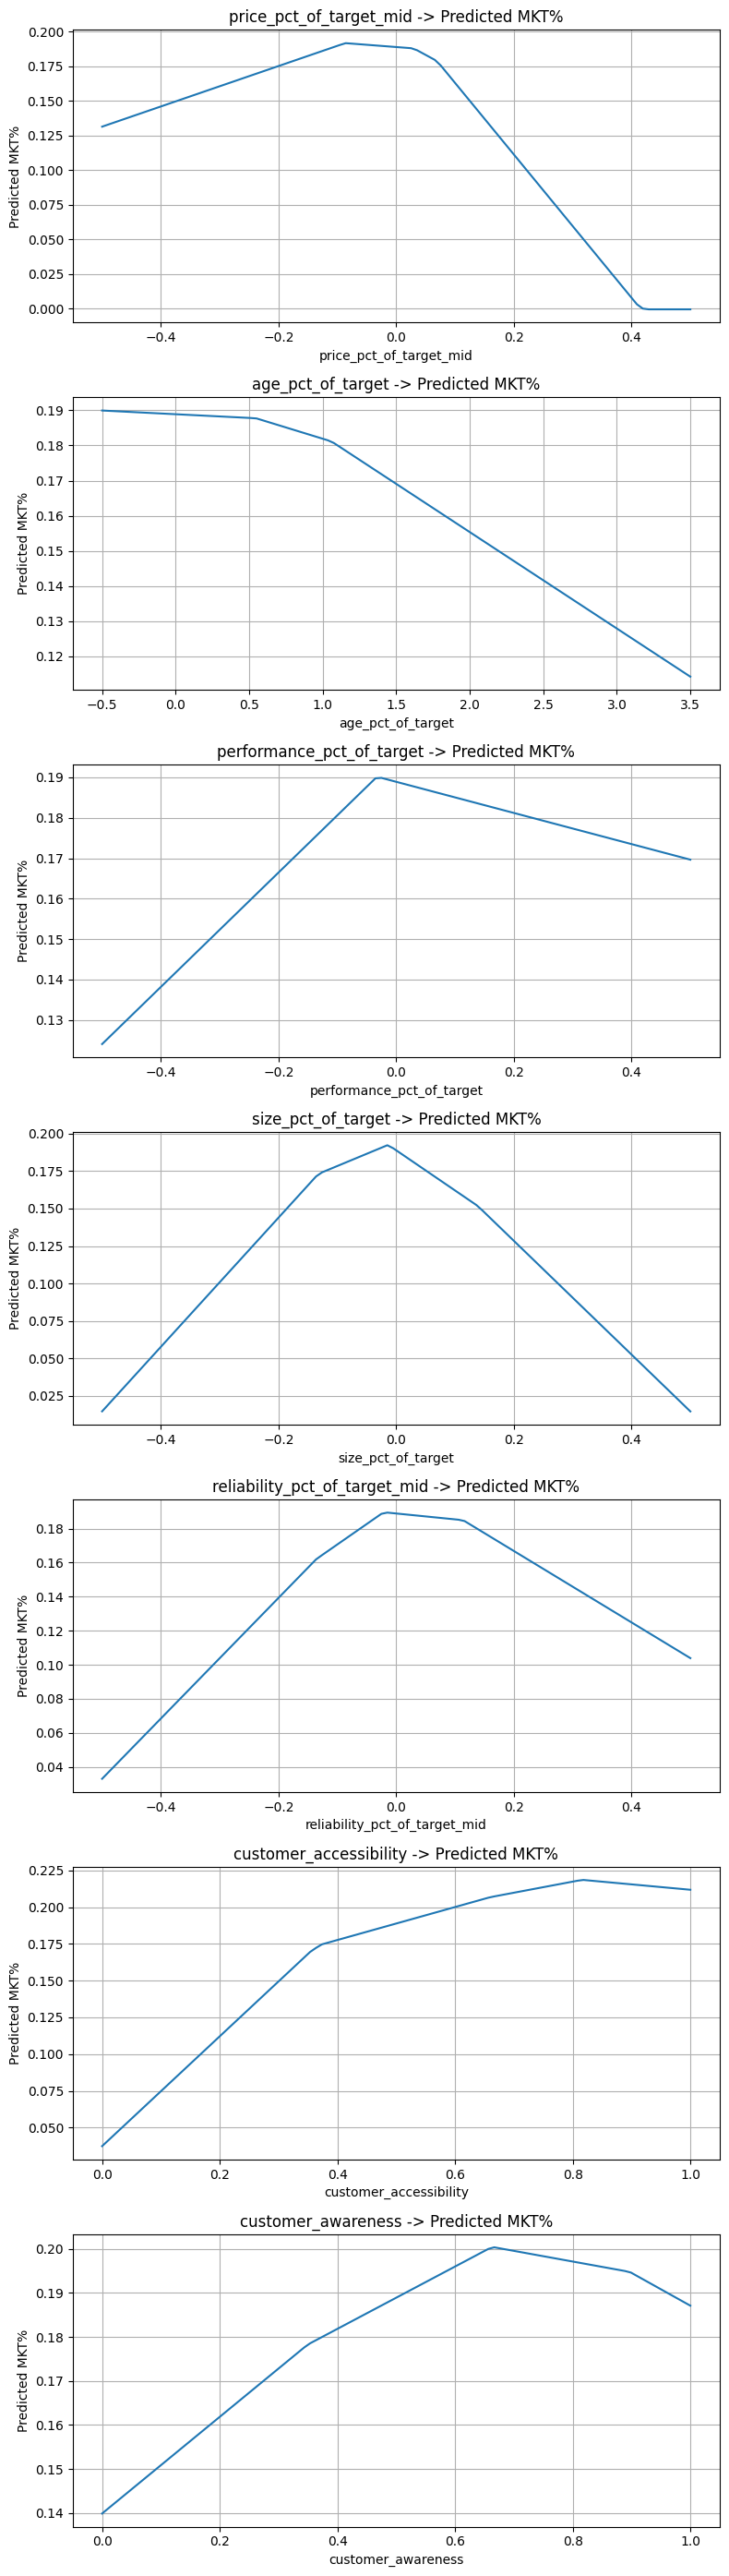

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


num_cols = [
    "price_pct_of_target_mid",
    "age_pct_of_target",
    "performance_pct_of_target",
    "size_pct_of_target",
    "reliability_pct_of_target_mid",
    "customer_accessibility",
    "customer_awareness"
]


base_sample = {
    "category_code": 4,
    "price_pct_of_target_mid": 0.00,
    "age_pct_of_target": 0.00,
    "performance_pct_of_target": 0.00,
    "size_pct_of_target": 0.00,
    "reliability_pct_of_target_mid": 0.00,
    "customer_accessibility": 0.5,
    "customer_awareness": 0.5
}


feature_ranges = {
    "price_pct_of_target_mid": (-0.5, 0.5),
    "age_pct_of_target": (-0.5, 3.5),
    "performance_pct_of_target": (-0.5, 0.5),
    "size_pct_of_target": (-0.5, 0.5),
    "reliability_pct_of_target_mid": (-0.5, 0.5),
    "customer_accessibility": (0.0, 1.0),
    "customer_awareness": (0.0, 1.0),
}


def plot_feature_sweeps_fast(model, base_sample, num_cols, feature_ranges, num_points=100):
    n_features = len(num_cols)
    total_rows = n_features * num_points

    # Base numeric row
    base_num = np.array([base_sample[col] for col in num_cols], dtype=np.float32)

    # Allocate one big batch
    x_num = np.tile(base_num, (total_rows, 1))
    x_cat = np.full((total_rows, 1), base_sample["category_code"], dtype=np.int32)

    # Keep sweep values so we can plot later
    sweep_map = {}

    # Fill batch
    row_start = 0
    for i, feature in enumerate(num_cols):
        lo, hi = feature_ranges[feature]
        sweep_vals = np.linspace(lo, hi, num_points, dtype=np.float32)
        sweep_map[feature] = sweep_vals

        row_end = row_start + num_points
        x_num[row_start:row_end, i] = sweep_vals
        row_start = row_end

    # One prediction call instead of hundreds
    preds = model.predict(
        {"numeric_features": x_num, "category": x_cat},
        verbose=0
    ).reshape(-1)

    # Plot
    fig, axes = plt.subplots(n_features, 1, figsize=(8, 4 * n_features), squeeze=False)
    axes = axes.ravel()

    row_start = 0
    for ax, feature in zip(axes, num_cols):
        row_end = row_start + num_points
        ax.plot(sweep_map[feature], preds[row_start:row_end])
        ax.set_title(f"{feature} -> Predicted MKT%")
        ax.set_xlabel(feature)
        ax.set_ylabel("Predicted MKT%")
        ax.grid(True)
        row_start = row_end

    plt.tight_layout()
    plt.show()


plot_feature_sweeps_fast(model, base_sample, num_cols, feature_ranges, num_points=100)

In [63]:
model.save("models/m-v5.keras")